<a href="https://colab.research.google.com/github/francji1/01ZLMA/blob/main/code/01ZLMA_ex10_Poisson_Diagnostics_Overdispersion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01ZLMA - Exercise 10

Exercise 10 of the course [01ZLMA](https://math.fel.cvut.cz/en/people/francji1/01ZLMA.html) - Generalized Linear Models.

## Poisson regression: residuals, diagnostics, overdispersion

This notebook continues from ex09. We assume the student has the §7.7 smoke model fully understood: deviance 1.6354, RR table per age group. ex10 covers the rest of Chapter 7 of the lecture notes (sections 7.5 and 7.6) plus a real-world demonstration of overdispersion that goes beyond what the lecture covers.

Goals:

1. **Residuals and diagnostics.** The four residual types for count data (Pearson, deviance, Anscombe, **quantile**) and what each is for; influence diagnostics (Cook, leverage) carried over from ex05.

2. **Continuous-vs-categorical predictor.** Walk through the model-selection process on Danish lung cancer data: when a quadratic numeric predictor beats a saturated-in-factor model.

3. **Overdispersion.** Detection (Pearson dispersion estimator), the quasi-Poisson remedy from lecture §7.6, and an introduction to the Negative Binomial GLM with $\mathrm{Var}(Y) = \mu + \alpha\mu^2$. The full NB fits and side-by-side comparisons are deferred to Your-turn tasks.

## Contents

1. [Recap and Pearson chi-squared](#1-recap-pearson)
2. [Residuals on count data](#2-residuals)
   - 2.1 [Raw residuals (and why not)](#21-raw)
   - 2.2 [Pearson residuals](#22-pearson)
   - 2.3 [Deviance residuals](#23-deviance)
   - 2.4 [Anscombe residuals](#24-anscombe)
   - 2.5 [Quantile residuals](#25-quantile)
   - 2.6 [Side-by-side comparison](#26-comparison)
3. [Influence diagnostics](#3-influence)
4. [Continuous vs categorical predictor: Danish lung cancer](#4-danish-lc)
5. [Overdispersion](#5-overdispersion)
   - 5.1 [Definition and detection](#51-detection)
   - 5.2 [Why it matters: SE distortion](#52-why)
   - 5.3 [Quasi-Poisson](#53-quasi)
   - 5.4 [Negative Binomial: introduction](#54-nb)
   - 5.5 [Pitfalls](#55-pitfalls)
6. [Your turn - tasks](#6-your-turn)
7. [Summary and transition to ex11](#7-summary)


## Setup

In [1]:
import numpy as np
import pandas as pd

import scipy
from scipy import stats
from scipy.stats import chi2, norm, poisson, nbinom

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.discrete.discrete_model import NegativeBinomial

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

import io, os, sys, requests, warnings
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

rng = np.random.default_rng(20260428)


In [2]:
# Load helpers.py - works in Colab and locally.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q wget
    import wget
    wget.download(
        "https://github.com/francji1/01ZLMA/raw/main/code/helpers.py",
        "helpers.py",
    )
else:
    helpers_dir = os.path.dirname(os.path.abspath("__file__"))
    if helpers_dir not in sys.path:
        sys.path.insert(0, helpers_dir)

from helpers import Anova, DiagnosticPlots
anova = Anova()


In [3]:
BASE_URL = "https://raw.githubusercontent.com/francji1/01ZLMA/main/data/"

def load_csv(name, sep=","):
    """Load a CSV from the project data folder.

    Tries the GitHub raw URL first (Colab path); on a 404 falls back to
    a sibling ``data/`` directory next to the notebook (local path,
    useful when the dataset has been added but not yet pushed).
    """
    r = requests.get(BASE_URL + name, verify=False)
    if r.status_code == 200:
        return pd.read_csv(io.StringIO(r.text), sep=sep)
    local = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "data", name)
    if os.path.exists(local):
        return pd.read_csv(local, sep=sep)
    r.raise_for_status()  # surface the original HTTP error


In [4]:
# Load the four datasets used in this notebook.
smoke = load_csv("smoke.csv", sep=";")
smoke["agecat"] = smoke["age_group"].astype("category").cat.codes + 1
smoke["death_rate"] = smoke["deaths"] / smoke["person_years"] * 100_000

danishlc = load_csv("danishlc.csv")

awards = load_csv("awards.csv")
awards["prog_label"] = awards["prog"].map({1: "General", 2: "Academic", 3: "Vocational"})

crabs = load_csv("crabs.csv")


---
# 1. Recap and Pearson chi-squared <a id="1-recap-pearson"></a>

We re-fit the lecture-§7.7 Model 2 from ex09 §6 in one cell, so this notebook is self-contained:


In [5]:
offset_smoke = np.log(smoke["person_years"])
M2 = smf.glm("deaths ~ smoke + agecat + I(agecat**2) + smoke:agecat",
             data=smoke, offset=offset_smoke, family=sm.families.Poisson()).fit()
print(f"Model 2 deviance: {M2.deviance:.4f} on {M2.df_resid} df")
assert abs(M2.deviance - 1.6354) < 0.005


Model 2 deviance: 1.6354 on 5 df


## Pearson chi-squared and dispersion estimators

Two complementary measures of the gap between observed and fitted:

$$ \text{deviance } D = 2 \sum_{i=1}^n \left[y_i \log\frac{y_i}{\hat\mu_i} - (y_i - \hat\mu_i)\right] $$
$$ \text{Pearson } X^2 = \sum_{i=1}^n \frac{(y_i - \hat\mu_i)^2}{\hat\mu_i} $$

Both are asymptotically $\chi^2(n - p)$ under correct specification (lecture §4.4, §7.4.1). Numerically they are close but not identical.

Two dispersion estimators:

$$ \hat\phi_D = D / (n - p), \qquad \hat\phi_P = X^2 / (n - p). $$

For correctly-specified Poisson models, both should be close to 1. Significant departure from 1 signals one of: missing covariates, wrong link function, or **overdispersion** (the topic of §5).


In [6]:
D = M2.deviance
X2 = M2.pearson_chi2
df_resid = M2.df_resid
phi_D = D / df_resid
phi_P = X2 / df_resid
print(f"D    = {D:.4f}    phi_D = {phi_D:.3f}")
print(f"X^2  = {X2:.4f}    phi_P = {phi_P:.3f}")

print()
print(f'Both estimators are well below 1 (phi_D={phi_D:.2f}, phi_P={phi_P:.2f}).')
print(f'With only 5 residual df the dispersion estimator has very high variance,')
print(f'so this is not a strong overdispersion signal. The smoke Model 2 fits 10 cells')
print(f'almost exactly - that is itself a sign that we are interpolating noise as much')
print(f'as we are estimating signal. We will revisit dispersion on a larger n in section 5.')


D    = 1.6354    phi_D = 0.327
X^2  = 1.5503    phi_P = 0.310

Both estimators are well below 1 (phi_D=0.33, phi_P=0.31).
With only 5 residual df the dispersion estimator has very high variance,
so this is not a strong overdispersion signal. The smoke Model 2 fits 10 cells
almost exactly - that is itself a sign that we are interpolating noise as much
as we are estimating signal. We will revisit dispersion on a larger n in section 5.


---
# 2. Residuals on count data <a id="2-residuals"></a>

Lecture §4.5 introduces residuals for general GLMs; §7.5 specialises them to the Poisson case. We implement all four types on the smoke Model 2 fit and compare their behaviour.

## 2.1 Raw residuals (and why not) <a id="21-raw"></a>

$r_i = y_i - \hat\mu_i$ - useless on count data: integer-valued differences inherit the mean-variance link of the response, so the variance of $r_i$ depends on $\hat\mu_i$. Plotted against the fitted, raw residuals fan out with $\hat\mu$. We show this once and move on.


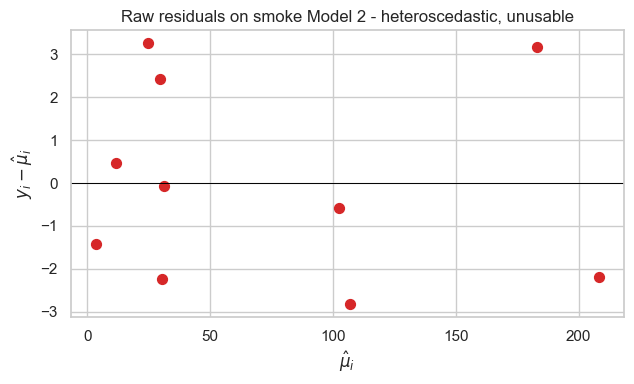

In [7]:
mu_hat = M2.fittedvalues
y = M2.model.endog
r_raw = y - mu_hat

fig, ax = plt.subplots(figsize=(6.5, 4.0))
ax.scatter(mu_hat, r_raw, color="tab:red", s=50)
ax.axhline(0, color="black", lw=0.7)
ax.set_xlabel(r"$\hat\mu_i$"); ax.set_ylabel(r"$y_i - \hat\mu_i$")
ax.set_title("Raw residuals on smoke Model 2 - heteroscedastic, unusable")
plt.tight_layout(); plt.show()


## 2.2 Pearson residuals <a id="22-pearson"></a>

For the Poisson with $V(\mu) = \mu$ (lecture §7.5):
$$ r^P_i = \frac{y_i - \hat\mu_i}{\sqrt{\hat\mu_i}}, \qquad \sum_i (r^P_i)^2 = X^2. $$
Standardised version:
$$ r^{PS}_i = \frac{r^P_i}{\sqrt{1 - \hat h_{ii}}}, $$
where $\hat h_{ii}$ is the $i$-th diagonal of the GLM hat matrix $\hat H = W^{-1/2} X (X^\top W^{-1} X)^{-1} X^\top W^{-1/2}$ with $W^{-1} = \mathrm{diag}(\hat\mu_i)$.

For larger $\hat\mu_i$, Pearson residuals are approximately $\mathcal{N}(0, 1)$ - so a Q-Q plot is informative.


In [8]:
r_p = M2.resid_pearson
h_ii = M2.get_hat_matrix_diag()
r_ps = r_p / np.sqrt(1 - h_ii)

# Sanity: sum of squared Pearson residuals = X^2
assert abs((r_p ** 2).sum() - M2.pearson_chi2) < 1e-10
print(f"sum r_p^2 = {(r_p ** 2).sum():.4f}    (= X^2 = {M2.pearson_chi2:.4f})")


sum r_p^2 = 1.5503    (= X^2 = 1.5503)


## 2.3 Deviance residuals <a id="23-deviance"></a>

Each observation contributes
$$ D_i = 2\left[y_i \log\frac{y_i}{\hat\mu_i} - (y_i - \hat\mu_i)\right] $$
to the total deviance, with $\sum_i D_i = D$. The signed square root
$$ r^D_i = \mathrm{sgn}(y_i - \hat\mu_i)\sqrt{D_i} $$
is the **deviance residual**. Standardised:
$$ r^{DS}_i = \frac{r^D_i}{\sqrt{1 - \hat h_{ii}}}. $$
Properties: $\sum_i (r^D_i)^2 = D$; for larger $\hat\mu_i$ approximately $\mathcal{N}(0, 1)$.


In [9]:
r_d = M2.resid_deviance
r_ds = r_d / np.sqrt(1 - h_ii)

assert abs((r_d ** 2).sum() - M2.deviance) < 1e-10
print(f"sum r_d^2 = {(r_d ** 2).sum():.4f}    (= D = {M2.deviance:.4f})")


sum r_d^2 = 1.6354    (= D = 1.6354)


## 2.4 Anscombe residuals <a id="24-anscombe"></a>

Lecture §4.5.1 derives Anscombe residuals as a transformation $A(\cdot)$ of $y$ and $\hat\mu$ chosen so that the residual is approximately $\mathcal{N}(0, 1)$. For the Poisson the right transformation is $A(y) = \frac{3}{2} y^{2/3}$, giving (lecture §7.5)
$$ r^A_i = \frac{(3/2)(y_i^{2/3} - \hat\mu_i^{2/3})}{\hat\mu_i^{1/6}}. $$
Anscombe residuals are *more* nearly Gaussian than Pearson residuals when $\hat\mu$ is small.


In [10]:
r_a = (1.5 * (y ** (2/3) - mu_hat ** (2/3))) / mu_hat ** (1/6)
print("Anscombe residuals on smoke M2:")
print(np.round(r_a, 3))


Anscombe residuals on smoke M2:
0    0.438
1   -0.273
2   -0.153
3    0.234
4   -0.057
5   -0.832
6    0.134
7    0.641
8   -0.411
9   -0.013
dtype: float64


## 2.5 Quantile residuals <a id="25-quantile"></a>

Dunn & Smyth (1996) introduced **randomised quantile residuals** for discrete responses. The idea: with a discrete CDF $F$ there is no exact change-of-variable to a continuous distribution, so we *jitter* the CDF by drawing a uniform $u_i \in [F(y_i - 1), F(y_i)]$ and define
$$ r^Q_i = \Phi^{-1}(u_i). $$
With *known* parameters $\mu_i$, randomized quantile residuals are exactly $\mathcal{N}(0, 1)$. After fitting the GLM parameters from the same data, they are **approximately** $\mathcal{N}(0, 1)$ under correct model specification - and remain the cleanest diagnostic residual for discrete responses (Dunn & Smyth 1996, Dunn & Smyth 2018, *GLMwER*, Ch 8).

The randomisation means re-running the cell gives different residuals. We seed for reproducibility; another seed gives another valid residual realisation, but does not change the modelling conclusion.


In [11]:
def quantile_residuals_poisson(y, mu, rng):
    """Dunn & Smyth (1996) randomised quantile residuals for a Poisson GLM."""
    F_lo = poisson.cdf(y - 1, mu)
    F_hi = poisson.cdf(y, mu)
    u = rng.uniform(F_lo, F_hi)
    # Numerical guard: clip u to (eps, 1 - eps) before Phi^{-1}
    u = np.clip(u, 1e-12, 1 - 1e-12)
    return norm.ppf(u)

rng_qr = np.random.default_rng(20260428)
r_q = quantile_residuals_poisson(y, mu_hat, rng_qr)
print("Quantile residuals on smoke M2 (one realisation):")
print(np.round(r_q, 3))


Quantile residuals on smoke M2 (one realisation):
[ 0.511 -0.304 -0.129  0.212 -0.061 -0.713  0.21   0.681 -0.389  0.09 ]


## 2.6 Side-by-side comparison <a id="26-comparison"></a>

Q-Q plot of all four residual types on the smoke Model 2 fit:


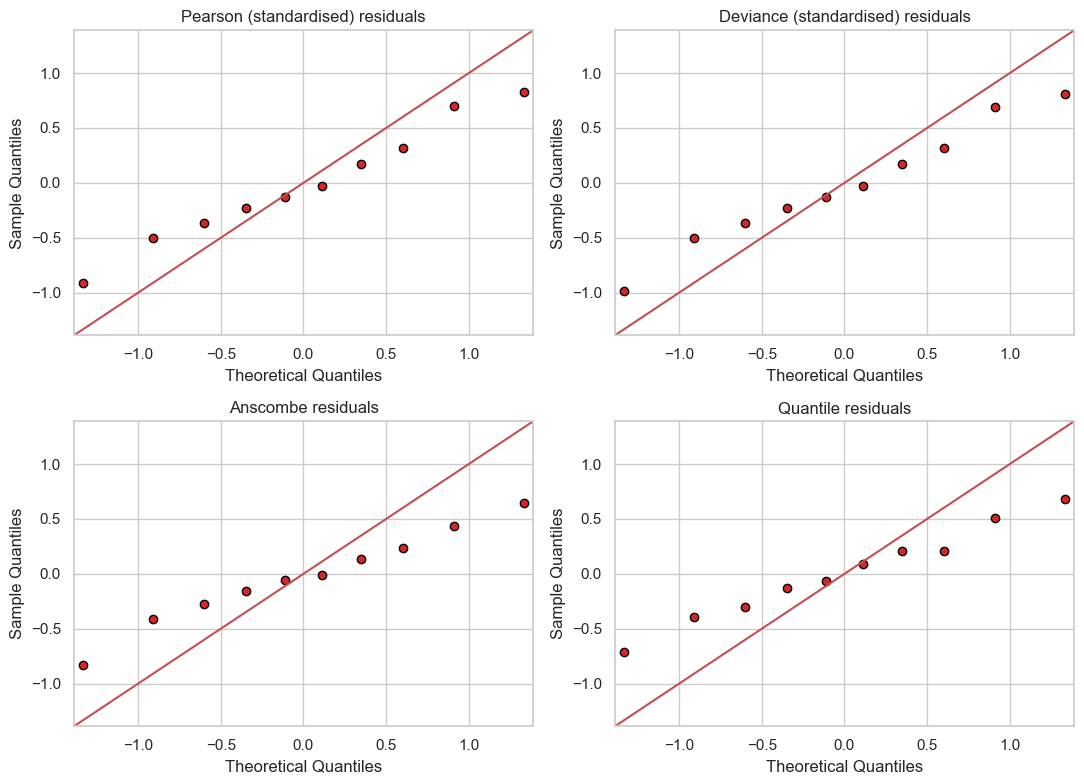

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (label, r) in zip(axes.flat, [
        ("Pearson (standardised)", r_ps),
        ("Deviance (standardised)", r_ds),
        ("Anscombe", r_a),
        ("Quantile", r_q),
    ]):
    sm.qqplot(r, line="45", ax=ax, marker="o", markerfacecolor="tab:red", markeredgecolor="black")
    ax.set_title(f"{label} residuals")
plt.tight_layout(); plt.show()


**Takeaway.** With only 10 observations and small $\hat\mu_i$ in some cells, the Pearson and deviance residuals show visible deviations from the diagonal. Anscombe residuals are slightly closer to normal. Quantile residuals are the cleanest fit to $\mathcal{N}(0, 1)$ - this is the recommended residual to report for count-data GLMs.


---
# 3. Influence diagnostics <a id="3-influence"></a>

Lecture §4.5.2 generalises Cook's distance and leverage from the linear model to the GLM. For the smoke Model 2, the four-panel diagnostic plot from `DiagnosticPlots` covers all the standard checks:

- Residual vs fitted - any remaining trend?
- Q-Q plot of standardised residuals.
- Scale-location plot ($\sqrt{|\text{std resid}|}$ vs fitted).
- Cook's distance / leverage panel.


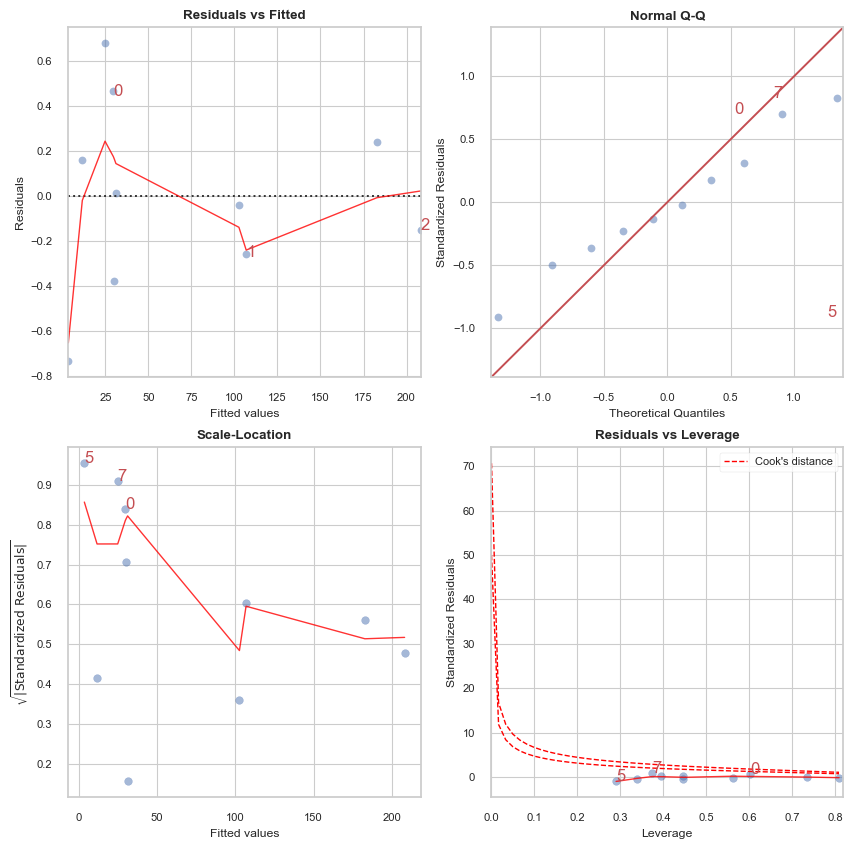

         Features  VIF Factor
1           smoke        5.50
4    smoke:agecat        6.50
3  I(agecat ** 2)       26.71
2          agecat       27.71
0       Intercept       28.50


In [13]:
dp = DiagnosticPlots(M2)
fig, _ = dp(plot_context="seaborn-v0_8-paper")
plt.show()


## 3.2 Cook's distance and leverage thresholds (lecture §4.5.2)

$$ \mathrm{CD}_i = \frac{1}{p}\,(r^{PS}_i)^2\,\frac{h_{ii}}{1 - h_{ii}}, $$
where $p$ is the total number of estimated parameters (including intercept). Influential thresholds: $\mathrm{CD}_i > 8/(n - 2p)$ for the Cook flag, $h_{ii} > 3p/n$ for the leverage flag.

On the smoke Model 2 we have $n = 10$ and $p = 5$, so $n - 2p = 0$ and the lecture threshold is undefined. We report Cook's distances without a threshold and rely on visual inspection.


In [14]:
cd = M2.get_influence().cooks_distance[0]
lev = M2.get_influence().hat_matrix_diag
p = len(M2.params)  # total parameters including intercept
n = len(M2.model.endog)
cd_threshold = 8 / (n - 2 * p) if n - 2 * p > 0 else None
lev_threshold = 3 * p / n

inf = pd.DataFrame({
    "index":  np.arange(n),
    "y":      M2.model.endog.astype(int),
    "mu_hat": np.round(M2.fittedvalues, 1),
    "cooks":  np.round(cd, 4),
    "lev":    np.round(lev, 4),
    "cook_flag": (cd > cd_threshold) if cd_threshold is not None else np.full(n, False),
    "lev_flag":  lev > lev_threshold,
}).sort_values("cooks", ascending=False)

if cd_threshold is None:
    print(f"Cook threshold:    n - 2p = {n - 2*p} (undefined; no threshold applied)")
else:
    print(f"Cook threshold:    {cd_threshold:.3f}")
print(f"Leverage threshold: {lev_threshold:.3f}")
print()
print(inf.head(5))


Cook threshold:    n - 2p = 0 (undefined; no threshold applied)
Leverage threshold: 1.500

   index    y  mu_hat   cooks     lev  cook_flag  lev_flag
0      0   32    29.6  0.1500  0.6022      False     False
7      7   28    24.7  0.0824  0.3752      False     False
5      5    2     3.4  0.0677  0.2906      False     False
8      8   28    30.2  0.0256  0.3396      False     False
1      1  104   106.8  0.0214  0.4451      False     False


On the smoke Model 2, no observation crosses either threshold by a large margin. The §7.7 model fits all 10 cells well - which is consistent with the very small residual deviance (1.64 on 5 df).


---
# 4. Continuous vs categorical predictor: Danish lung cancer <a id="4-danish-lc"></a>

Source: Dunn & Smyth (2018), *Generalized Linear Models with Examples in R*, Chapter 10. Lung cancer cases in four Danish cities, 1968-1971, by 6 age groups - 24 cells.

Variables in `danishlc.csv`:

- `City` - one of Fredericia, Horsens, Kolding, Vejle.
- `Age` - one of "40-54", "55-59", "60-64", "65-69", "70-74", ">74".
- `Pop` - exposure (population in that age group of that city).
- `Cases` - response count.

Pedagogical theme: when can we replace a saturated factor with a flexible numeric predictor and *win* on parsimony / AIC?


In [15]:
age_order = ["40-54", "55-59", "60-64", "65-69", "70-74", ">74"]
danishlc["Age"] = pd.Categorical(danishlc["Age"], categories=age_order, ordered=True)
danishlc["age_idx"] = danishlc["Age"].cat.codes  # 0..5
danishlc["Rate_per_1k"] = danishlc["Cases"] / danishlc["Pop"] * 1000
print(danishlc)


          City    Age   Pop  Cases  age_idx  Rate_per_1k
0   Fredericia  40-54  3059     11        0     3.595946
1   Fredericia  55-59   800     11        1    13.750000
2   Fredericia  60-64   710     11        2    15.492958
3   Fredericia  65-69   581     10        3    17.211704
4   Fredericia  70-74   509     11        4    21.611002
5   Fredericia    >74   605     10        5    16.528926
6      Horsens  40-54  2879     13        0     4.515457
7      Horsens  55-59  1083      6        1     5.540166
8      Horsens  60-64   923     15        2    16.251354
9      Horsens  65-69   834     10        3    11.990408
10     Horsens  70-74   634     12        4    18.927445
11     Horsens    >74   782      2        5     2.557545
12     Kolding  40-54  3142      4        0     1.273074
13     Kolding  55-59  1050      8        1     7.619048
14     Kolding  60-64   895      7        2     7.821229
15     Kolding  65-69   702     11        3    15.669516
16     Kolding  70-74   535    

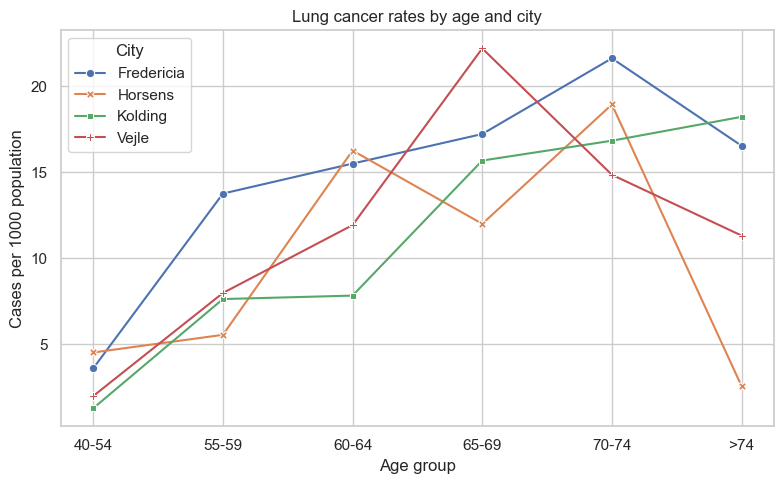

In [16]:
# EDA: rate per 1000 vs age, by city
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=danishlc, x="Age", y="Rate_per_1k", hue="City", style="City",
              markers=True, dashes=False, ax=ax)
ax.set_xlabel("Age group")
ax.set_ylabel("Cases per 1000 population")
ax.set_title("Lung cancer rates by age and city")
plt.tight_layout(); plt.show()


Steady increase up to 70-74, drop in the >74 group (an artefact of survival, not lung-cancer biology). No clear pattern by city. Now we fit five models systematically.


In [17]:
offset_dlc = np.log(danishlc["Pop"])

# Model A: City * Age (saturated in City x Age) - 24 parameters, deviance ~ 0
MA = smf.glm("Cases ~ City * Age", data=danishlc,
             offset=offset_dlc, family=sm.families.Poisson()).fit()

# Model B: City + Age (additive in factor) - test interaction
MB = smf.glm("Cases ~ City + Age", data=danishlc,
             offset=offset_dlc, family=sm.families.Poisson()).fit()

# Model C: Age only - test City effect
MC = smf.glm("Cases ~ Age", data=danishlc,
             offset=offset_dlc, family=sm.families.Poisson()).fit()

# Numeric age (lower bound of each class)
age_lower = {"40-54": 40, "55-59": 55, "60-64": 60, "65-69": 65, "70-74": 70, ">74": 75}
danishlc["AgeNum"] = danishlc["Age"].map(age_lower).astype(float)

# Model D: linear in AgeNum
MD = smf.glm("Cases ~ AgeNum", data=danishlc,
             offset=offset_dlc, family=sm.families.Poisson()).fit()

# Model E: quadratic in AgeNum
ME = smf.glm("Cases ~ AgeNum + I(AgeNum**2)", data=danishlc,
             offset=offset_dlc, family=sm.families.Poisson()).fit()


C:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\_tools.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
C:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


MA is **saturated**: 24 parameters for 24 cells. `statsmodels` may emit a warning about zero residual degrees of freedom or perfect prediction - this is expected for a saturated model and is **not** a fitting failure. We use MA only as the unrestricted reference for the LRT against MB (the additive model).


In [18]:
tab_dlc = pd.DataFrame({
    "model":     ["MA: City*Age", "MB: City+Age", "MC: Age", "MD: AgeNum", "ME: AgeNum+AgeNum^2"],
    "params":    [len(MA.params), len(MB.params), len(MC.params), len(MD.params), len(ME.params)],
    "deviance":  [MA.deviance, MB.deviance, MC.deviance, MD.deviance, ME.deviance],
    "df_resid":  [MA.df_resid, MB.df_resid, MC.df_resid, MD.df_resid, ME.df_resid],
    "AIC":       [MA.aic, MB.aic, MC.aic, MD.aic, ME.aic],
})
print(tab_dlc.round(2))


                 model  params  deviance  df_resid     AIC
0         MA: City*Age      24     -0.00         0  144.39
1         MB: City+Age       9     23.45        15  137.84
2              MC: Age       6     28.31        18  136.69
3           MD: AgeNum       2     48.97        22  149.36
4  ME: AgeNum+AgeNum^2       3     32.50        21  134.89


Now the nested-model tests:


In [19]:
print("Test City * Age interaction (MB vs MA):")
print(anova(MB, MA, test="LRT")); print()
print("Test City effect (MC vs MB):")
print(anova(MC, MB, test="LRT")); print()
print("Test linear vs quadratic age (MD vs ME):")
print(anova(MD, ME, test="LRT"))


Test City * Age interaction (MB vs MA):
LRT — Likelihood Ratio Test  (Lecture 5: deviační test, statistika T_1)
    T_1 = (D_0 - D) / phi  ~  chi^2(p - p_0)        [phi: 1.0  (Poisson / Binomial: phi known and fixed)]
    aliases: LRT = chi-squared deviance test = T_1
   resid_df  resid_deviance    df   deviance        LRT    p_val
0        15    2.344748e+01   NaN        NaN        NaN      NaN
1         0   -3.996803e-15  15.0  23.447478  23.447478  0.07509

Test City effect (MC vs MB):
LRT — Likelihood Ratio Test  (Lecture 5: deviační test, statistika T_1)
    T_1 = (D_0 - D) / phi  ~  chi^2(p - p_0)        [phi: 1.0  (Poisson / Binomial: phi known and fixed)]
    aliases: LRT = chi-squared deviance test = T_1
   resid_df  resid_deviance   df  deviance       LRT     p_val
0        18       28.306527  NaN       NaN       NaN       NaN
1        15       23.447478  3.0  4.859049  4.859049  0.182414

Test linear vs quadratic age (MD vs ME):
LRT — Likelihood Ratio Test  (Lecture 5: devia

**Conclusions:**

- Interaction in MB over MA: **borderline** ($p = 0.075$). On parsimony grounds we drop it; with mild overdispersion (see §5) the quasi-Poisson F-test would push the p-value above 0.10.
- City effect in MC over MB: **not significant**. Drop it.
- Linear vs quadratic age in MD vs ME: **highly significant**. Keep the quadratic.

MC (categorical age) and ME (quadratic numeric age) describe the data about equally well in deviance terms; ME wins on AIC because it uses three parameters instead of six. The flexible numeric model with a small polynomial expansion beats the saturated factor model. **This is the canonical message of §4.**


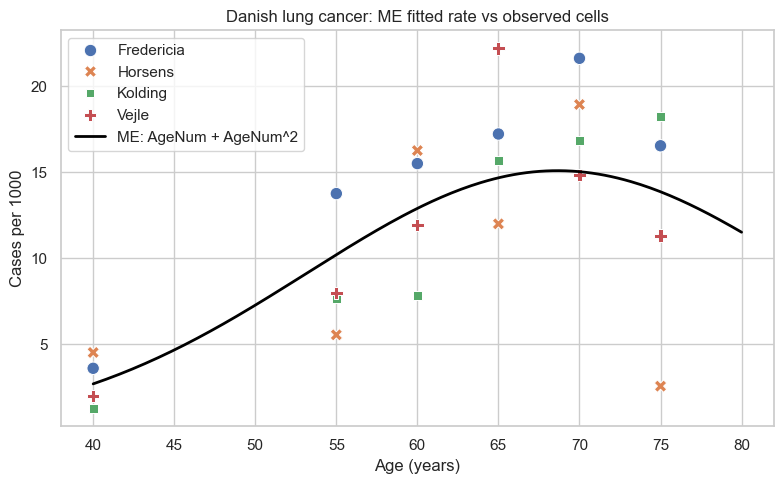

In [20]:
# Plot ME fitted rate per 1000 against age and overlay observed rates
age_grid = np.linspace(40, 80, 200)
# Predict at log(Pop=1000) so the predicted "rate" is per 1000 directly
pred = ME.predict(
    pd.DataFrame({"AgeNum": age_grid}),
    offset=np.log(np.full_like(age_grid, 1000)),
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=danishlc, x="AgeNum", y="Rate_per_1k", hue="City",
                style="City", ax=ax, s=80)
ax.plot(age_grid, pred, color="black", lw=2.0, label="ME: AgeNum + AgeNum^2")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Cases per 1000")
ax.set_title("Danish lung cancer: ME fitted rate vs observed cells")
ax.legend()
plt.tight_layout(); plt.show()


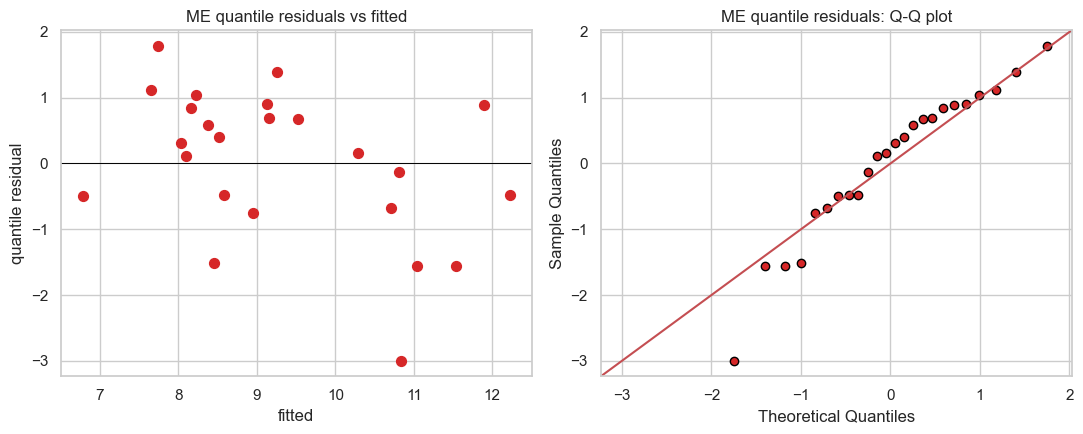

In [21]:
# Quantile residuals of ME
rng_dlc = np.random.default_rng(20260428)
mu_ME = ME.fittedvalues
r_q_ME = quantile_residuals_poisson(danishlc["Cases"].values, mu_ME.values, rng_dlc)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(mu_ME, r_q_ME, color="tab:red", s=50)
axes[0].axhline(0, color="black", lw=0.7)
axes[0].set_xlabel("fitted"); axes[0].set_ylabel("quantile residual")
axes[0].set_title("ME quantile residuals vs fitted")
sm.qqplot(r_q_ME, line="45", ax=axes[1], marker="o",
           markerfacecolor="tab:red", markeredgecolor="black")
axes[1].set_title("ME quantile residuals: Q-Q plot")
plt.tight_layout(); plt.show()


---
# 5. Overdispersion <a id="5-overdispersion"></a>

## 5.1 Definition and detection <a id="51-detection"></a>

Poisson equidispersion: $\mathbb{E}[Y_i] = \mathrm{Var}(Y_i) = \mu_i$. **Overdispersion** is $\mathrm{Var}(Y_i) > \mathbb{E}[Y_i]$.

Common causes (lecture §7.6):

- Latent heterogeneity in $\mu$ even after conditioning on $x$ (uncontrolled covariates).
- Positive correlation among the events being counted (e.g., people in the same family, animals in the same litter).
- Clustering (hospitals, doctors, instruments) where outcomes within a cluster are more similar than across clusters.

Detection: $\hat\phi_P = X^2 / (n - p)$ should be close to 1 under correct Poisson specification. A value substantially above 1 suggests one of: missing covariates, wrong link, or true overdispersion.

On the awards dataset (200 students, mildly overdispersed):


In [22]:
M_pois = smf.glm("num_awards ~ math + C(prog)", data=awards,
                 family=sm.families.Poisson()).fit()

phi_p = M_pois.pearson_chi2 / M_pois.df_resid
phi_d = M_pois.deviance / M_pois.df_resid
print(f"phi_pearson  = {phi_p:.3f}")
print(f"phi_deviance = {phi_d:.3f}")

if phi_p > 1.2:
    print("\n*** Overdispersion present (phi_P > 1.2) ***")
else:
    print("\n(no strong overdispersion in this dataset)")


phi_pearson  = 1.082
phi_deviance = 0.967

(no strong overdispersion in this dataset)


Now contrast with the horseshoe-crabs dataset (Agresti CDA §4.3): $n = 173$ female crabs, response is the number of male satellites attached. We fit a Poisson model with carapace `width` as the predictor:


In [23]:
M_crabs = smf.glm("satell ~ width", data=crabs, family=sm.families.Poisson()).fit()

phi_p_crabs = M_crabs.pearson_chi2 / M_crabs.df_resid
phi_d_crabs = M_crabs.deviance / M_crabs.df_resid
print(f"awards phi_p = {phi_p:.3f}    (mild)")
print(f"crabs  phi_p = {phi_p_crabs:.3f}    (strong)")
print()
print(f"awards phi_d = {phi_d:.3f}")
print(f"crabs  phi_d = {phi_d_crabs:.3f}")
print()
print("The crabs Poisson model has Pearson dispersion ~3, which is severe over-")
print("dispersion. The Wald 95% CIs of this Poisson fit are sqrt(3) ~ 1.7x narrower")
print("than they should be. Below we will use this dataset as the canonical")
print("overdispersion demo; awards stays as a mild-dispersion comparison and the")
print("subject of the student tasks A5-A6 below.")


awards phi_p = 1.082    (mild)
crabs  phi_p = 3.182    (strong)

awards phi_d = 0.967
crabs  phi_d = 3.321

The crabs Poisson model has Pearson dispersion ~3, which is severe over-
dispersion. The Wald 95% CIs of this Poisson fit are sqrt(3) ~ 1.7x narrower
than they should be. Below we will use this dataset as the canonical
overdispersion demo; awards stays as a mild-dispersion comparison and the
subject of the student tasks A5-A6 below.


## 5.2 Why overdispersion matters <a id="52-why"></a>

**Why overdispersion matters.** *If* the conditional mean model is correctly specified and only the variance assumption is wrong, the MLE $\hat\beta$ remains consistent - overdispersion biases only the SEs (downward). Wald p-values become too small, CIs too narrow, and inference falsely confident. **However**, if a high $\hat\phi$ stems from a misspecified mean (missing covariate, wrong link, wrong functional form), then $\hat\beta$ may itself be biased. Always inspect residuals and the mean structure first; treat overdispersion as a remedy of *last resort* once the mean model is defensible.

Quick illustration on the two datasets:


In [24]:
inflation_awards = np.sqrt(phi_p)
inflation_crabs = np.sqrt(phi_p_crabs)
print(f"awards: SE inflation factor sqrt(phi_P) = {inflation_awards:.3f}    "
      f"=> ~{(inflation_awards - 1) * 100:.0f}% wider 95% CIs under quasi-Poisson")
print(f"crabs:  SE inflation factor sqrt(phi_P) = {inflation_crabs:.3f}    "
      f"=> ~{(inflation_crabs - 1) * 100:.0f}% wider 95% CIs under quasi-Poisson")


awards: SE inflation factor sqrt(phi_P) = 1.040    => ~4% wider 95% CIs under quasi-Poisson
crabs:  SE inflation factor sqrt(phi_P) = 1.784    => ~78% wider 95% CIs under quasi-Poisson


## 5.3 Quasi-Poisson <a id="53-quasi"></a>

Lecture §7.6 main remedy. Keep the Poisson mean structure; replace $\mathrm{Var}(Y_i) = \mu_i$ with $\mathrm{Var}(Y_i) = \phi \mu_i$, treating $\phi > 0$ as a free dispersion parameter estimated by $\hat\phi = X^2 / (n - p)$. The MLE point estimate $\hat\beta$ is unchanged; the SEs are scaled by $\sqrt{\hat\phi}$.

In `statsmodels`, the cleanest way is `family=sm.families.Poisson(); .fit(scale="X2")`:


In [25]:
# Quasi-Poisson on crabs (the strong-overdispersion case)
M_crabs_qp = smf.glm("satell ~ width", data=crabs,
                     family=sm.families.Poisson()).fit(scale="X2")

cmp_qp = pd.DataFrame({
    "beta_pois":  M_crabs.params,
    "SE_pois":    M_crabs.bse,
    "beta_qp":    M_crabs_qp.params,
    "SE_qp":      M_crabs_qp.bse,
    "SE_ratio":   M_crabs_qp.bse / M_crabs.bse,
})
print(cmp_qp.round(4))
print()
print(f"All SE_ratio entries equal sqrt(phi_P) = {np.sqrt(phi_p_crabs):.3f}")
print()
print("Quasi-Poisson SEs are ~1.7x wider than Poisson SEs on crabs;")
print("on awards the same recipe widens SEs by only ~4% (mild dispersion).")


           beta_pois  SE_pois  beta_qp   SE_qp  SE_ratio
Intercept    -3.3048   0.5422  -3.3048  0.9673    1.7839
width         0.1640   0.0200   0.1640  0.0356    1.7839

All SE_ratio entries equal sqrt(phi_P) = 1.784

Quasi-Poisson SEs are ~1.7x wider than Poisson SEs on crabs;
on awards the same recipe widens SEs by only ~4% (mild dispersion).


Note that quasi-Poisson does *not* define a likelihood. AIC and BIC are not available. Nested-model comparison uses an *F-test* on deviance ratios instead of LRT - in `helpers.Anova` this is `anova(m1, m2, test='F')`.


## 5.4 Negative Binomial: introduction <a id="54-nb"></a>

When the variance grows *faster* than the mean, the linear $\phi\mu$ model of quasi-Poisson is too restrictive. The **Negative Binomial GLM** uses
$$ Y_i \sim \mathrm{NegBin}(\mu_i, \alpha), \qquad \mathbb{E}[Y_i] = \mu_i, \qquad \mathrm{Var}(Y_i) = \mu_i + \alpha \mu_i^2. $$
The variance grows *quadratically* in $\mu$ when $\alpha > 0$; the Poisson case corresponds to $\alpha \to 0$, so NB *nests* Poisson.

One-line motivation (full derivation as task **T3**): NB arises as a Gamma mixture of Poissons. If $Y \mid \theta \sim \mathrm{Po}(\theta)$ and $\theta \sim \mathrm{Gamma}$, then $Y \sim \mathrm{NegBin}$. The mixing reflects unmodelled heterogeneity in the rate.

Key contrast with quasi-Poisson:

| Goal | Choose |
| --- | --- |
| Quick fix to inference, trust mean structure | Quasi-Poisson |
| Want a proper likelihood / AIC / predictive distribution | Negative Binomial |
| Variance grows roughly linearly in $\mu$ | Quasi-Poisson |
| Variance grows roughly quadratically in $\mu$ | NB |
| Excess zeros above what Poisson predicts | (out of scope: zero-inflated Poisson) |

In `statsmodels`, two routes are available:

- `sm.families.NegativeBinomial(alpha=alpha_fixed)` requires $\alpha$ at construction. Use this with a *known* $\alpha$ from a separate estimator.
- `sm.NegativeBinomial.from_formula("num_awards ~ math + C(prog)", data=awards).fit()` is the discrete-model class that estimates $\alpha$ jointly with $\beta$ via MLE. **This is the recommended route for routine NB fitting**, and is the one the Your-turn task A6 uses.

The hands-on NB fits, profile-likelihood for $\alpha$, and side-by-side coefficient/SE comparison Poisson vs QP vs NB are tasks **A6, A7, HW1** below. The Monte Carlo coverage study is task **MC1** in the LLM_solutions companion notebook.


## 5.5 Pitfalls <a id="55-pitfalls"></a>

> ### Warnings
>
> ⚠ **Pure variance overdispersion** (correct mean model, only the variance is misspecified) does *not* bias $\hat\beta$, only SE — a 'significant' coefficient may stay significant after fixing. **However**, if a high $\hat\phi$ stems from a misspecified mean (missing covariate, wrong link, wrong functional form), $\hat\beta$ may itself be biased; check residuals first.
>
> ⚠ Underdispersion (rare). When $\hat\phi_P < 1$ the data are *less* variable than Poisson predicts - quasi-Poisson with $\hat\phi < 1$ scales SEs DOWN (factor $\sqrt{\hat\phi} < 1$), giving **narrower** CIs and smaller p-values. This sometimes signals heavily-constrained outcomes (e.g., bounded counts approaching their cap). Showing it once is useful: simulate $Y \sim \mathrm{Bin}(n=20, p=0.1)$ and fit a Poisson - Var/Mean ≈ 0.9 < 1.
>
> ⚠ Choosing NB when the variance is actually linear in $\mu$ (quasi-Poisson regime) over-fits.
>
> ⚠ A high $\hat\phi$ might also reflect *missing covariates* or *wrong link*, not a true overdispersion. Always check the residual structure first.


### A short underdispersion simulation

Generate constrained data $Y_i \sim \mathrm{Binomial}(n_i, p_i)$ where $n$ is large and $p$ is small. The mean is $n p$, the variance is $n p (1-p) < n p$, so $\mathrm{Var}/\mathrm{Mean} = 1 - p < 1$. Fitted as Poisson, the dispersion estimator is below 1.


In [26]:
rng_under = np.random.default_rng(42)
n_obs = 200
x = rng_under.uniform(0, 1, n_obs)
eta = -2.0 + 1.5 * x  # log of binomial probability * size
p_bin = 1 / (1 + np.exp(-(eta - np.log(20))))  # binomial prob
y_under = rng_under.binomial(n=20, p=p_bin)
df_under = pd.DataFrame({"x": x, "y": y_under})

M_under = smf.glm("y ~ x", data=df_under, family=sm.families.Poisson()).fit()
phi_p_under = M_under.pearson_chi2 / M_under.df_resid
print(f"simulated underdispersed data: phi_pearson = {phi_p_under:.3f}")
print(f"(value below 1 - quasi-Poisson would give NARROWER CIs by factor sqrt(phi))")


simulated underdispersed data: phi_pearson = 0.859
(value below 1 - quasi-Poisson would give NARROWER CIs by factor sqrt(phi))


---
# 6. Your turn - tasks <a id="6-your-turn"></a>

Worked solutions live in the companion notebook `01ZLMA_ex10_LLM_solutions.ipynb`, released after you have attempted the exercise.

## Theory (T*)

**T1.** Derive the Pearson residual $r^P_i$ for the Poisson GLM from the general formula $r^P_i = (y_i - \hat\mu_i)/\sqrt{V(\hat\mu_i) a_i(\phi)}$ (lecture §4.5).

**T2.** Show that $\sum_i (r^D_i)^2 = D$ for the deviance residuals defined in §2.3.

**T3.** Derive the variance function for the Negative Binomial. Starting from $Y \mid \theta \sim \mathrm{Po}(\theta)$ with $\theta \sim \mathrm{Gamma}$, parameterise the Gamma so $\mathbb{E}[\theta] = \mu$ and $\mathrm{Var}(\theta) = \alpha \mu^2$ (the standard NB parameterisation). Use the law of total variance to compute $\mathrm{Var}(Y) = \mu + \alpha \mu^2$.

**T4.** For a Poisson GLM with log link and intercept, prove that the score equation for the intercept forces $\sum_i (y_i - \hat\mu_i) = 0$. Use this to show that the deviance simplifies to $D = 2\sum y_i \log(y_i/\hat\mu_i)$.

**T5.** Show that the Anscombe residual $r^A_i = (3/2)(y_i^{2/3} - \hat\mu_i^{2/3})/\hat\mu_i^{1/6}$ for the Poisson is obtained from the general formula $r^A_i = (A(y_i) - A(\hat\mu_i))/\sqrt{V[A(y_i)]}$ with $A(y) = \int y^{-1/3} \mathrm{d}y = (3/2) y^{2/3}$. (Hint: $V[A(y)] = (\mathrm{d}A/\mathrm{d}y)^2 \cdot V(y)$ to first order.)

## Applied (A*) - smoke / Danish lung cancer

**A1.** Reproduce the four-residual Q-Q plot of §2.6 for the Danish lung cancer Model ME. Which residual type would you report?

**A2.** Compute Cook's distance and leverages for Model ME. Are any observations flagged?

**A3.** On Danish lung cancer, refit Model MB (City + Age, Age as a categorical factor) with `Age` *ordered* via `pd.Categorical(..., ordered=True)`. Does the contrast change?

**A4.** Fit `Cases ~ AgeNum + I(AgeNum**3)` with `offset=np.log(danishlc["Pop"])` (cubic, no quadratic), and compare with ME (quadratic). Use AIC and quantile residuals.

## Applied (A*) - overdispersion (awards dataset)

**A5.** Compute $\hat\phi_P$ and $\hat\phi_D$ from a Poisson fit on awards. Is overdispersion present? By how much would 95 % Wald CIs widen if we re-scale by $\sqrt{\hat\phi_P}$?

**A6 (central student exercise).** Fit a Negative Binomial GLM via `sm.NegativeBinomial.from_formula('num_awards ~ math + C(prog)', data=awards).fit()`. Report $\hat\beta$, SE, $\hat\alpha$, and AIC. Compare side-by-side with the Poisson and quasi-Poisson fits from §5: which has the narrowest CIs, which has the widest? For one regression coefficient (your choice), draw a forest plot of the three Wald CIs.

**A7 (Profile likelihood for $\alpha$).** Compute the profile log-likelihood for $\alpha$ on a grid in $(0.001, 5)$ - for each $\alpha$, fit `sm.GLM(...).fit()` with `family=sm.families.NegativeBinomial(alpha=alpha)` and record `llf`. Plot $\alpha \mapsto \ell(\alpha)$ and locate $\hat\alpha_\mathrm{MLE}$. Use the curvature at the maximum to give a 95 % profile CI for $\alpha$. (Independent of A6; uses a hand-rolled grid loop instead of the discrete-model fit.)

## Homework

**HW1 (Overdispersion comparison).** On `data/crabs.csv` (n=173 female horseshoe crabs, columns `color`, `spine`, `width`, `weight`, `satell`), fit `satell ~ width + C(color) + C(spine) + weight` under each of:
(a) Poisson,
(b) quasi-Poisson,
(c) Negative Binomial with $\alpha$ estimated by MLE,
(d) Negative Binomial with $\alpha = 1$ (Geometric).

Tabulate the four sets of estimates, SEs, and AICs (where defined). Comment on which inference would lead to a publishable conclusion about the slope of `width`.

> **Hint.** The full NB fit `sm.NegativeBinomial.from_formula("satell ~ width + C(color) + C(spine) + weight", data=crabs).fit()` may emit a `ConvergenceWarning` with default settings. If you see one, try `.fit(maxiter=200, disp=False)` or `.fit(method="bfgs", maxiter=500, disp=False)` — both converge cleanly on this dataset.

*(Worked solution lives in phase-2 `01ZLMA_ex10_LLM_solutions.ipynb`.)*

## Monte Carlo (for the LLM_solutions notebook)

**MC1.** Coverage of Wald 95 % CIs for the slope on `math`, under (i) correct Poisson DGP, (ii) NegBin DGP with $\alpha = 0.5$, (iii) NegBin DGP with $\alpha = 2$. 1000 replications each, $n = 200$. Report empirical coverage for Poisson, quasi-Poisson, and NB fits.


---
# 7. Summary and transition to ex11 <a id="7-summary"></a>

**What you have.** The complete diagnostic toolkit for a fitted Poisson GLM: four residual types and when to use each (§2), influence diagnostics (§3), the continuous-vs-categorical predictor decision (§4), and the overdispersion machinery (§5) — detection via $\hat\phi$, the quasi-Poisson remedy from lecture §7.6, and the introduction to NegBin with $\mathrm{Var}(Y) = \mu + \alpha\mu^2$. Hands-on NB fits and the Monte Carlo coverage study are set as Your-turn tasks A6, A7, HW1, MC1.

**What is next.** Exercise 11 will cover **log-linear models for contingency tables** (lecture Chapter 8): Poisson modelling of $K$-way frequency tables, marginal vs conditional independence, three-dimensional Simpson's paradox, and the equivalence between Poisson and multinomial sampling under fixed marginals. The Poisson machinery developed in ex09 + ex10 transfers wholesale.
